In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# Demo: Entangling gates using Rydberg interactions

In this notebook, you'll investigate how to entangle two atoms using a CZ gate implemented via the Rydberg blockade. The protocol you'll use is sometimes referred to as the $\pi$-$2\pi$-$\pi$ scheme. Below you can find an illustration of the pulse sequence that's used. The protocol works by imprinting a _conditional phase_ on a state -- you'll discover what that means below.

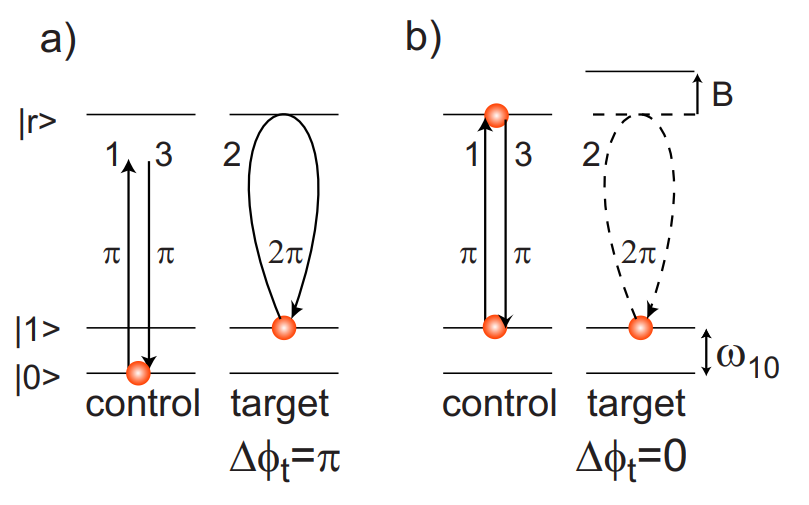

[Saffman, Molmer, and Walker; Rev. Mod. Phys. **82** (2010)]

## Setting up the Hamiltonian

We begin by setting up the individual Hamiltonians that describe the coupling of the $|1\rangle$ state to the Rydberg state $|r\rangle$. We cannot use the state labels when indexing arrays, so we order them in our numerical basis in the order of $|0\rangle$, $|1\rangle$, and $|r\rangle$.

We define the coupling between $|1\rangle$ and $|r\rangle$ as $\Omega$, and use `V` to refer to the interaction between two atoms in the Rydberg state. It's set to some finite value here.

In [ ]:
Ω = 2*np.pi
V = 10*2*np.pi
tπ = np.pi/Ω

Hsingle = Ω/2 * qt.basis(3, 1) * qt.basis(3, 2).dag()
Hsingle += Hsingle.dag()
Hsingle

This is a single-atom Hamiltonian, we'll need to expand this to the two-atom basis later on.

We set up the interaction in the two-atom basis directly. The energy of the $|rr\rangle$ state is `V`, which we add using the $|rr\rangle\langle rr|$ projector. We use QuTiP's `tensor()` function here. This is a function that allows us to combine multiple quantum systems: in this case two atoms.

When going from the single- to the two-atom basis the total number of states needs to expand. In the single-atom basis there are just three states: $|0\rangle$, $|1\rangle$, and $|r\rangle$. In the two-qubit basis we need all combinations like $|00\rangle$, $|r1\rangle$, and so on, which totals to nine states. The `tensor()` function allows us to do this systematically.

In [ ]:
proj_r = qt.basis(3, 2) * qt.basis(3, 2).dag()
Hint = V * qt.tensor(proj_r, proj_r)
Hint

We need some way to program the time-dependent pulses. They are:
1. $\pi$ pulse applied to the control atom.
2. $2\pi$ pulse applied to the target atom.
3. $\pi$ pulse applied to the control atom again.

The easiest way to do this is via a time-dependent function that's either 0 or 1, and which multiplies the overall Hamiltonian terms.

In [ ]:
def ct(t):
    # Control atom function
    if t < tπ:
        return 1.0
    elif t > 3*tπ and t < 4*tπ:
        return 1.0
    else:
        return 0.0

def tt(t):
    # Target atom function
    if t > tπ and t < 3*tπ:
        return np.float64(1.0)
    else:
        return np.float64(0.0)

timeax = np.linspace(0, 4*tπ, 100)
plt.plot(timeax, [ct(t) for t in timeax], label = "Control amplitude")
plt.plot(timeax, [tt(t) for t in timeax], label = "Target amplitude")
plt.legend()
plt.xlabel("Time ($2\\pi/\\Omega$)", fontsize = 12)
plt.ylabel("Laser amplitude (arb.)", fontsize = 12)

## Calculating the evolution

Everything together now. To encode the time dependence, we use a quantum object that consists of pairs like `[Operator, time function]`. From there on QuTiP deals with the rest, and we calculate the propagator, which is the operator $U$ that describes the effect of our gate on an intial state, like:

$$
|\psi_\mathrm{final}\rangle = U|\psi_\mathrm{initial}\rangle.
$$

In [ ]:
Htot = qt.QobjEvo(
        [Hint,
        [qt.tensor(Hsingle, qt.qeye(3)), ct],
        [qt.tensor(qt.qeye(3), Hsingle), tt]]
)
U_gate = qt.propagator(Htot, np.max(timeax), options = {'nsteps': 100000})
U_gate

## Chopping down the basis
In an actual circuit this is inconvenient. There are nine states for two qubits, while most circuit simulators use four states for two qubits. The reason is that we still account for the $|r\rangle$ state, even though it contains hardly any population if the gate has been carried out correctly.

We can solve this by projecting the operator $U$ on the two qubit basis, meaning we remove any state that contains $r$ from the basis. In linear algebra terms it means that we remove the rows and columns that correspond to these states, so that all we have left is the basis $|00\rangle$, $|01\rangle$, $|10\rangle$, and $|11\rangle$.

In [ ]:
P = np.zeros((4, 9))
to_keep = [0, 1, 3, 4]
for (i, k) in enumerate(to_keep):
    P[i, k] = 1

Up = (P @ U_gate.data.to_array() @ P.T)
qt.Qobj(Up, dims = [[2, 2], [2, 2]])

## What happened here?
If we look at the steps in the protocol again, we can try to understand what happened here:
1. $\pi$ pulse applied to the control atom.
2. $2\pi$ pulse applied to the target atom.
3. $\pi$ pulse applied to the control atom again.

Where do the minus signs in the gate matrix come from? Well, it's important to realize that a full rotation (by $2\pi$) doesn't _quite_ return a qubit back to its initial state. In terms of population it does, but it also results in a phase pickup of $-1$.

What happens to the states in the basis?
- The first state in the basis, $|00\rangle$ doesn't undergo any rotation whatsoever, so there's no extra phse.
- In the second and third states, $|01\rangle$ and $|10\rangle$, _either_ the control or target atom undergoes a full rotation, resulting in a phase of $-1$.
- In fourth state, $|11\rangle$, _only_ the control atom undergoes a full rotation; due to the interaction the target is blockaded, meaning it stays put. If the interaction strength were zero the control state would also undergo a rotation, resulting in a double phase pickup of $(-1) * (-1) = 1$. The resulting evolution would be _separable_, meaning it can always be described in terms of the evolution of the individual states. No entanglement could be created using this operation.